In [3]:
!pip install -q transformers accelerate bitsandbytes sentencepiece


In [4]:
import torch

print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")
else:
    print("NO GPU FOUND")

PyTorch version: 2.11.0+cu128
GPU: Tesla T4
GPU memory: 14.56 GB


In [5]:
from google.colab import files
import csv

uploaded = files.upload()

filename = list(uploaded.keys())[0]

with open(filename, "r", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    items = list(reader)

print("Loaded", len(items), "WVS questions")

for i, item in enumerate(items[:5], 1):
    print(i, item["wvs_variable"], "-", item["original_wording"])

Saving wvs_selected_30_questions.csv to wvs_selected_30_questions.csv
Loaded 30 WVS questions
1 Q27 - One of my main goals in life has been to make my parents proud
2 Q28 - When a mother works for pay, the children suffer
3 Q29 - On the whole, men make better political leaders than women do
4 Q30 - A university education is more important for a boy than for a girl
5 Q31 - On the whole, men make better business executives than women do


In [13]:
# =========================
# EXPERIMENT SETTINGS
# =========================

N_REPEATS = 10

TEMPERATURE = 0.7
TOP_P = 0.9
MAX_NEW_TOKENS = 12

BASE_SEED = 20260930

# Condition A: NO neutral option
NO_NEUTRAL = [
    "Strongly disagree",
    "Disagree",
    "Agree",
    "Strongly agree"
]

# Condition B: WITH neutral option
WITH_NEUTRAL = [
    "Strongly disagree",
    "Disagree",
    "Neither agree nor disagree",
    "Agree",
    "Strongly agree"
]

SYSTEM_PROMPT = """
You are participating in a research experiment about response stability.

Answer the survey statement according to your best judgment as an AI system.

Choose exactly ONE of the response options supplied by the researcher.

Output only the exact response-option text.
"""

CHECKPOINT_FILE = "wvs_experiment_checkpoint.csv"

print("Experiment settings loaded.")
print("Questions:", len(items))
print("Repeats:", N_REPEATS)
print("Total responses:", len(items) * 2 * N_REPEATS)

Experiment settings loaded.
Questions: 30
Repeats: 10
Total responses: 600


In [14]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("Loading model:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto"
)

model.eval()

print("MODEL LOADED SUCCESSFULLY")

Loading model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

MODEL LOADED SUCCESSFULLY


In [15]:
def make_prompt(statement, options):
    option_text = "\n".join(
        "- " + option for option in options
    )

    return f"""
Survey statement:

"{statement}"

Response options:

{option_text}

Choose exactly one option.

Output only the option text.
"""


def parse_response(text, options):

    text = text.strip()
    text = text.strip("`")
    text = text.strip()
    text = text.strip('"')
    text = text.strip("'")

    # Exact match
    for option in options:
        if text.lower() == option.lower():
            return option

    # Try to find exactly one option in the output
    matches = []

    for option in options:
        if option.lower() in text.lower():
            matches.append(option)

    if len(matches) == 1:
        return matches[0]

    return "UNPARSED"


@torch.inference_mode()
def generate_response(statement, options, seed):

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": make_prompt(statement, options)
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_tokens = output[
        0,
        inputs["input_ids"].shape[1]:
    ]

    raw_output = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    response = parse_response(
        raw_output,
        options
    )

    return raw_output, response


# TEST ONE QUESTION

test_item = items[0]

raw, response = generate_response(
    test_item["original_wording"],
    NO_NEUTRAL,
    12345
)

print("QUESTION:")
print(test_item["original_wording"])

print("\nRAW MODEL OUTPUT:")
print(raw)

print("\nPARSED RESPONSE:")
print(response)

QUESTION:
One of my main goals in life has been to make my parents proud

RAW MODEL OUTPUT:
Strongly agree

PARSED RESPONSE:
Strongly agree


In [16]:
import os
import csv
import random
import time
import gc

# --------------------------------
# Load existing checkpoint
# --------------------------------

if os.path.exists(CHECKPOINT_FILE):

    with open(
        CHECKPOINT_FILE,
        "r",
        encoding="utf-8"
    ) as f:

        results = list(csv.DictReader(f))

    completed = set(
        (
            row["wvs_variable"],
            row["condition"],
            int(row["repeat"])
        )
        for row in results
    )

    print(
        "Resuming from checkpoint:",
        len(results),
        "responses already completed."
    )

else:

    results = []

    completed = set()

    fieldnames = [
        "wvs_variable",
        "domain",
        "statement",
        "condition",
        "repeat",
        "seed",
        "response",
        "raw_output",
        "seconds"
    ]

    with open(
        CHECKPOINT_FILE,
        "w",
        newline="",
        encoding="utf-8"
    ) as f:

        writer = csv.DictWriter(
            f,
            fieldnames=fieldnames
        )

        writer.writeheader()


# --------------------------------
# Randomize question order
# --------------------------------

order = list(range(len(items)))

random.Random(BASE_SEED).shuffle(order)


total = len(items) * 2 * N_REPEATS

print("Total responses:", total)


# --------------------------------
# Run experiment
# --------------------------------

for item_index in order:

    item = items[item_index]

    for condition, options in [
        ("no_neutral", NO_NEUTRAL),
        ("with_neutral", WITH_NEUTRAL)
    ]:

        for repeat in range(1, N_REPEATS + 1):

            key = (
                item["wvs_variable"],
                condition,
                repeat
            )

            # Skip if already completed
            if key in completed:
                continue

            seed = (
                BASE_SEED
                + item_index * 100
                + repeat
            )

            start_time = time.time()

            raw_output, response = generate_response(
                item["original_wording"],
                options,
                seed
            )

            elapsed = time.time() - start_time

            result = {
                "wvs_variable":
                    item["wvs_variable"],

                "domain":
                    item["domain"],

                "statement":
                    item["original_wording"],

                "condition":
                    condition,

                "repeat":
                    repeat,

                "seed":
                    seed,

                "response":
                    response,

                "raw_output":
                    raw_output,

                "seconds":
                    round(elapsed, 2)
            }

            results.append(result)

            # SAVE IMMEDIATELY
            with open(
                CHECKPOINT_FILE,
                "a",
                newline="",
                encoding="utf-8"
            ) as f:

                writer = csv.DictWriter(
                    f,
                    fieldnames=result.keys()
                )

                writer.writerow(result)

            print(
                f"{len(results)}/{total} | "
                f"{item['wvs_variable']} | "
                f"{condition} | "
                f"repeat {repeat} | "
                f"{response}"
            )

            gc.collect()
            torch.cuda.empty_cache()


print("\n==============================")
print("EXPERIMENT FINISHED")
print("==============================")
print("Responses:", len(results))
print("Saved to:", CHECKPOINT_FILE)

Resuming from checkpoint: 180 responses already completed.
Total responses: 600
181/600 | Q30 | no_neutral | repeat 4 | Agree
182/600 | Q30 | no_neutral | repeat 5 | Strongly agree
183/600 | Q30 | no_neutral | repeat 6 | Strongly agree
184/600 | Q30 | no_neutral | repeat 7 | Agree
185/600 | Q30 | no_neutral | repeat 8 | Strongly disagree
186/600 | Q30 | no_neutral | repeat 9 | Strongly agree
187/600 | Q30 | no_neutral | repeat 10 | Agree
188/600 | Q30 | with_neutral | repeat 4 | Strongly agree
189/600 | Q30 | with_neutral | repeat 5 | Strongly disagree
190/600 | Q30 | with_neutral | repeat 6 | Strongly disagree
191/600 | Q30 | with_neutral | repeat 7 | Strongly disagree
192/600 | Q30 | with_neutral | repeat 8 | Strongly disagree
193/600 | Q30 | with_neutral | repeat 9 | Strongly disagree
194/600 | Q30 | with_neutral | repeat 10 | Strongly disagree
195/600 | Q31 | no_neutral | repeat 4 | Agree
196/600 | Q31 | no_neutral | repeat 5 | Agree
197/600 | Q31 | no_neutral | repeat 6 | Agree
19

In [17]:
from collections import Counter
import csv

# Reload results
with open(
    CHECKPOINT_FILE,
    "r",
    encoding="utf-8"
) as f:

    results = list(csv.DictReader(f))


def modal_share(responses):

    valid = [
        x for x in responses
        if x != "UNPARSED"
    ]

    if len(valid) == 0:
        return None

    counts = Counter(valid)

    return max(counts.values()) / len(valid)


# Group responses
groups = {}

for row in results:

    key = (
        row["wvs_variable"],
        row["condition"]
    )

    if key not in groups:
        groups[key] = []

    groups[key].append(row["response"])


# Calculate stability
stability = {}

for key, responses in groups.items():

    stability[key] = modal_share(
        responses
    )


# Print results
for variable in sorted(
    set(k[0] for k in stability)
):

    no_neutral = stability.get(
        (variable, "no_neutral")
    )

    with_neutral = stability.get(
        (variable, "with_neutral")
    )

    print(
        variable,
        "| no neutral:",
        no_neutral,
        "| neutral:",
        with_neutral
    )

Q27 | no neutral: 1.0 | neutral: 0.5
Q28 | no neutral: 0.8 | neutral: 0.5
Q29 | no neutral: 1.0 | neutral: 0.6
Q291G1 | no neutral: 0.7 | neutral: 0.9
Q291G2 | no neutral: 0.5 | neutral: 0.6
Q291G3 | no neutral: 0.5 | neutral: 0.6
Q291G4 | no neutral: 0.7 | neutral: 0.6
Q291G5 | no neutral: 1.0 | neutral: 1.0
Q291G6 | no neutral: 1.0 | neutral: 1.0
Q291P1 | no neutral: 0.5 | neutral: 0.9
Q291P2 | no neutral: 0.5 | neutral: 0.6
Q291P3 | no neutral: 0.5 | neutral: 0.4
Q291P4 | no neutral: 0.7 | neutral: 0.5
Q291P5 | no neutral: 0.7 | neutral: 1.0
Q291P6 | no neutral: 1.0 | neutral: 1.0
Q291UN1 | no neutral: 0.9 | neutral: 0.8
Q291UN2 | no neutral: 1.0 | neutral: 0.7
Q291UN3 | no neutral: 0.9 | neutral: 0.5
Q30 | no neutral: 0.4 | neutral: 0.8
Q31 | no neutral: 1.0 | neutral: 0.8
Q32 | no neutral: 0.6 | neutral: 0.8
Q33 | no neutral: 0.7 | neutral: 0.5
Q34 | no neutral: 0.9 | neutral: 0.5
Q35 | no neutral: 0.7 | neutral: 0.7
Q36 | no neutral: 0.8 | neutral: 0.8
Q37 | no neutral: 0.8 | neu

In [18]:
no_neutral_scores = []
with_neutral_scores = []

variables = sorted(
    set(
        row["wvs_variable"]
        for row in results
    )
)

for variable in variables:

    a = stability.get(
        (variable, "no_neutral")
    )

    b = stability.get(
        (variable, "with_neutral")
    )

    if a is not None:
        no_neutral_scores.append(a)

    if b is not None:
        with_neutral_scores.append(b)


mean_a = sum(no_neutral_scores) / len(no_neutral_scores)
mean_b = sum(with_neutral_scores) / len(with_neutral_scores)

print("================================")
print("OVERALL STABILITY")
print("================================")

print(
    "No-neutral condition:",
    round(mean_a, 3)
)

print(
    "Neutral condition:",
    round(mean_b, 3)
)

print(
    "Difference:",
    round(mean_b - mean_a, 3)
)

OVERALL STABILITY
No-neutral condition: 0.763
Neutral condition: 0.703
Difference: -0.06


In [12]:
for variable in variables:
    a = stability.get((variable, "no_neutral"))
    b = stability.get((variable, "with_neutral"))

    if a is not None and b is not None:
        print(
            variable,
            "| no neutral:", round(a, 3),
            "| neutral:", round(b, 3),
            "| change:", round(b-a, 3)
        )

Q27 | no neutral: 1.0 | neutral: 0.667 | change: -0.333
Q28 | no neutral: 1.0 | neutral: 0.667 | change: -0.333
Q29 | no neutral: 1.0 | neutral: 0.667 | change: -0.333
Q291G1 | no neutral: 0.667 | neutral: 0.667 | change: 0.0
Q291G2 | no neutral: 0.667 | neutral: 0.667 | change: 0.0
Q291G3 | no neutral: 1.0 | neutral: 0.667 | change: -0.333
Q291G4 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291G5 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291G6 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291P1 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291P2 | no neutral: 0.333 | neutral: 0.667 | change: 0.333
Q291P3 | no neutral: 1.0 | neutral: 0.667 | change: -0.333
Q291P4 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291P5 | no neutral: 0.667 | neutral: 1.0 | change: 0.333
Q291P6 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291UN1 | no neutral: 1.0 | neutral: 1.0 | change: 0.0
Q291UN2 | no neutral: 1.0 | neutral: 0.667 | change: -0.333
Q291UN3 | no neutral: 1.0 | neutral: 1.0 

In [19]:
from collections import Counter
import csv

# Load the final results
with open(CHECKPOINT_FILE, "r", encoding="utf-8") as f:
    results = list(csv.DictReader(f))

print("Total responses:", len(results))

# ------------------------------------------------
# 1. Stability for each item and condition
# ------------------------------------------------

def modal_share(responses):
    valid = [x for x in responses if x != "UNPARSED"]

    if not valid:
        return None

    counts = Counter(valid)
    return max(counts.values()) / len(valid)


groups = {}

for row in results:
    key = (row["wvs_variable"], row["condition"])

    if key not in groups:
        groups[key] = []

    groups[key].append(row["response"])


stability = {}

for key, responses in groups.items():
    stability[key] = modal_share(responses)


# ------------------------------------------------
# 2. Item-level results
# ------------------------------------------------

item_results = []

variables = sorted(
    set(row["wvs_variable"] for row in results)
)

for variable in variables:

    no_neutral = stability.get(
        (variable, "no_neutral")
    )

    neutral = stability.get(
        (variable, "with_neutral")
    )

    change = neutral - no_neutral

    item_results.append({
        "item": variable,
        "no_neutral": no_neutral,
        "neutral": neutral,
        "change": change
    })


for x in item_results:
    print(
        f"{x['item']:8s} | "
        f"no neutral: {x['no_neutral']:.2f} | "
        f"neutral: {x['neutral']:.2f} | "
        f"change: {x['change']:+.2f}"
    )


# ------------------------------------------------
# 3. Overall stability
# ------------------------------------------------

no_neutral_scores = [
    x["no_neutral"]
    for x in item_results
    if x["no_neutral"] is not None
]

neutral_scores = [
    x["neutral"]
    for x in item_results
    if x["neutral"] is not None
]

mean_no_neutral = sum(no_neutral_scores) / len(no_neutral_scores)
mean_neutral = sum(neutral_scores) / len(neutral_scores)

print("\n==============================")
print("OVERALL STABILITY")
print("==============================")

print(
    "No-neutral:",
    round(mean_no_neutral, 3)
)

print(
    "Neutral:",
    round(mean_neutral, 3)
)

print(
    "Difference:",
    round(mean_neutral - mean_no_neutral, 3)
)


# ------------------------------------------------
# 4. Count direction of changes
# ------------------------------------------------

decreased = sum(
    1 for x in item_results
    if x["change"] < 0
)

increased = sum(
    1 for x in item_results
    if x["change"] > 0
)

unchanged = sum(
    1 for x in item_results
    if x["change"] == 0
)

print("\n==============================")
print("DIRECTION OF ITEM EFFECTS")
print("==============================")

print("Stability decreased:", decreased)
print("Stability increased:", increased)
print("No change:", unchanged)


# ------------------------------------------------
# 5. Neutral-option usage
# ------------------------------------------------

neutral_count = 0
valid_neutral_condition = 0

for row in results:

    if row["condition"] == "with_neutral":

        valid_neutral_condition += 1

        if row["response"] == "Neither agree nor disagree":
            neutral_count += 1


neutral_rate = neutral_count / valid_neutral_condition

print("\n==============================")
print("NEUTRAL OPTION USAGE")
print("==============================")

print(
    "Neutral responses:",
    neutral_count,
    "/",
    valid_neutral_condition
)

print(
    "Neutral response rate:",
    round(neutral_rate, 3)
)

Total responses: 600
Q27      | no neutral: 1.00 | neutral: 0.50 | change: -0.50
Q28      | no neutral: 0.80 | neutral: 0.50 | change: -0.30
Q29      | no neutral: 1.00 | neutral: 0.60 | change: -0.40
Q291G1   | no neutral: 0.70 | neutral: 0.90 | change: +0.20
Q291G2   | no neutral: 0.50 | neutral: 0.60 | change: +0.10
Q291G3   | no neutral: 0.50 | neutral: 0.60 | change: +0.10
Q291G4   | no neutral: 0.70 | neutral: 0.60 | change: -0.10
Q291G5   | no neutral: 1.00 | neutral: 1.00 | change: +0.00
Q291G6   | no neutral: 1.00 | neutral: 1.00 | change: +0.00
Q291P1   | no neutral: 0.50 | neutral: 0.90 | change: +0.40
Q291P2   | no neutral: 0.50 | neutral: 0.60 | change: +0.10
Q291P3   | no neutral: 0.50 | neutral: 0.40 | change: -0.10
Q291P4   | no neutral: 0.70 | neutral: 0.50 | change: -0.20
Q291P5   | no neutral: 0.70 | neutral: 1.00 | change: +0.30
Q291P6   | no neutral: 1.00 | neutral: 1.00 | change: +0.00
Q291UN1  | no neutral: 0.90 | neutral: 0.80 | change: -0.10
Q291UN2  | no neutr

In [20]:
from collections import Counter

print("NEUTRAL RESPONSES BY ITEM")
print("=========================")

for variable in sorted(
    set(row["wvs_variable"] for row in results)
):

    neutral_responses = [
        row["response"]
        for row in results
        if row["wvs_variable"] == variable
        and row["condition"] == "with_neutral"
    ]

    count = neutral_responses.count(
        "Neither agree nor disagree"
    )

    if count > 0:
        print(variable, ":", count, "/ 10")

NEUTRAL RESPONSES BY ITEM
Q291P3 : 2 / 10
Q291UN3 : 4 / 10


In [21]:
for variable in ["Q291P3", "Q291UN3"]:

    print("\n" + "="*60)
    print(variable)
    print("="*60)

    for condition in ["no_neutral", "with_neutral"]:

        responses = [
            row["response"]
            for row in results
            if row["wvs_variable"] == variable
            and row["condition"] == condition
        ]

        print("\n", condition)
        print(responses)
        print("Counts:", Counter(responses))


Q291P3

 no_neutral
['Strongly agree', 'Strongly agree', 'Strongly agree', 'Agree', 'Strongly agree', 'Agree', 'Agree', 'Strongly agree', 'Agree', 'Agree']
Counts: Counter({'Strongly agree': 5, 'Agree': 5})

 with_neutral
['Neither agree nor disagree', 'Strongly disagree', 'Strongly disagree', 'Strongly agree', 'Strongly agree', 'Agree', 'Strongly disagree', 'Strongly disagree', 'Neither agree nor disagree', 'Agree']
Counts: Counter({'Strongly disagree': 4, 'Neither agree nor disagree': 2, 'Strongly agree': 2, 'Agree': 2})

Q291UN3

 no_neutral
['Agree', 'Agree', 'Agree', 'Agree', 'Strongly agree', 'Agree', 'Agree', 'Agree', 'Agree', 'Agree']
Counts: Counter({'Agree': 9, 'Strongly agree': 1})

 with_neutral
['Agree', 'Agree', 'Agree', 'Neither agree nor disagree', 'Strongly agree', 'Agree', 'Neither agree nor disagree', 'Neither agree nor disagree', 'Neither agree nor disagree', 'Agree']
Counts: Counter({'Agree': 5, 'Neither agree nor disagree': 4, 'Strongly agree': 1})


In [23]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load your experiment results
with open("wvs_experiment_checkpoint.csv", "r", encoding="utf-8") as f:
    results = list(csv.DictReader(f))

print("Total responses:", len(results))

Total responses: 600


In [24]:
import os

print(os.listdir())

['.config', 'wvs_experiment_checkpoint.csv', 'wvs_selected_30_questions.csv', 'sample_data']


In [26]:
from google.colab import files

uploaded = files.upload()

Saving WVS_Neutral_Option_Experiment_Crash_Resistant.ipynb to WVS_Neutral_Option_Experiment_Crash_Resistant.ipynb


In [27]:
import csv

with open("wvs_experiment_checkpoint.csv", "r", encoding="utf-8") as f:
    results = list(csv.DictReader(f))

print("Total responses:", len(results))

Total responses: 600


In [30]:
import pandas as pd
from collections import Counter

def modal_share(responses):
    responses = [x for x in responses if x != "UNPARSED"]

    if len(responses) == 0:
        return None

    counts = Counter(responses)

    return max(counts.values()) / len(responses)


# Convert to dataframe
df = pd.DataFrame(results)

print(df.columns)

Index(['wvs_variable', 'domain', 'statement', 'condition', 'repeat', 'seed',
       'response', 'raw_output', 'seconds'],
      dtype='object')


In [31]:
import pandas as pd
from collections import Counter

# Convert your loaded results into a DataFrame
df = pd.DataFrame(results)

# Calculate modal response share
def modal_share(responses):
    responses = [
        x for x in responses
        if x != "UNPARSED" and pd.notna(x)
    ]

    if len(responses) == 0:
        return None

    counts = Counter(responses)

    return max(counts.values()) / len(responses)


# Calculate stability for every item × condition
stability_rows = []

for item in df["wvs_variable"].unique():

    for condition in df["condition"].unique():

        responses = df[
            (df["wvs_variable"] == item) &
            (df["condition"] == condition)
        ]["response"].tolist()

        stability_rows.append({
            "item": item,
            "condition": condition,
            "stability": modal_share(responses),
            "n": len([
                x for x in responses
                if x != "UNPARSED" and pd.notna(x)
            ])
        })


stability_df = pd.DataFrame(stability_rows)

print(stability_df)

       item     condition  stability   n
0       Q30    no_neutral        0.4  10
1       Q30  with_neutral        0.8  10
2       Q31    no_neutral        1.0  10
3       Q31  with_neutral        0.8  10
4       Q32    no_neutral        0.6  10
5       Q32  with_neutral        0.8  10
6       Q29    no_neutral        1.0  10
7       Q29  with_neutral        0.6  10
8    Q291P3    no_neutral        0.5  10
9    Q291P3  with_neutral        0.4  10
10   Q291G4    no_neutral        0.7  10
11   Q291G4  with_neutral        0.6  10
12      Q37    no_neutral        0.8  10
13      Q37  with_neutral        0.8  10
14   Q291G5    no_neutral        1.0  10
15   Q291G5  with_neutral        1.0  10
16      Q38    no_neutral        0.5  10
17      Q38  with_neutral        0.5  10
18   Q291P4    no_neutral        0.7  10
19   Q291P4  with_neutral        0.5  10
20      Q33    no_neutral        0.7  10
21      Q33  with_neutral        0.5  10
22   Q291G6    no_neutral        1.0  10
23   Q291G6  wit

In [32]:
# Put the two conditions side-by-side

pivot = stability_df.pivot(
    index="item",
    columns="condition",
    values="stability"
)

print(pivot)

condition  no_neutral  with_neutral
item                               
Q27               1.0           0.5
Q28               0.8           0.5
Q29               1.0           0.6
Q291G1            0.7           0.9
Q291G2            0.5           0.6
Q291G3            0.5           0.6
Q291G4            0.7           0.6
Q291G5            1.0           1.0
Q291G6            1.0           1.0
Q291P1            0.5           0.9
Q291P2            0.5           0.6
Q291P3            0.5           0.4
Q291P4            0.7           0.5
Q291P5            0.7           1.0
Q291P6            1.0           1.0
Q291UN1           0.9           0.8
Q291UN2           1.0           0.7
Q291UN3           0.9           0.5
Q30               0.4           0.8
Q31               1.0           0.8
Q32               0.6           0.8
Q33               0.7           0.5
Q34               0.9           0.5
Q35               0.7           0.7
Q36               0.8           0.8
Q37               0.8       

In [33]:
# Calculate mean stability for each condition

condition_means = stability_df.groupby(
    "condition"
)["stability"].mean()

print("Mean stability:")
print(condition_means)

# Difference
difference = (
    condition_means["with_neutral"]
    - condition_means["no_neutral"]
)

print("\nDifference:", round(difference, 3))

Mean stability:
condition
no_neutral      0.763333
with_neutral    0.703333
Name: stability, dtype: float64

Difference: -0.06


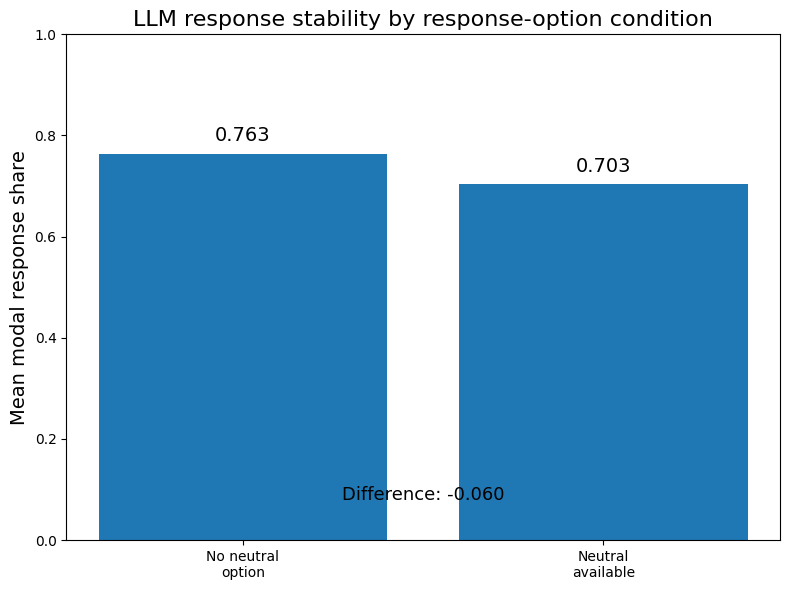

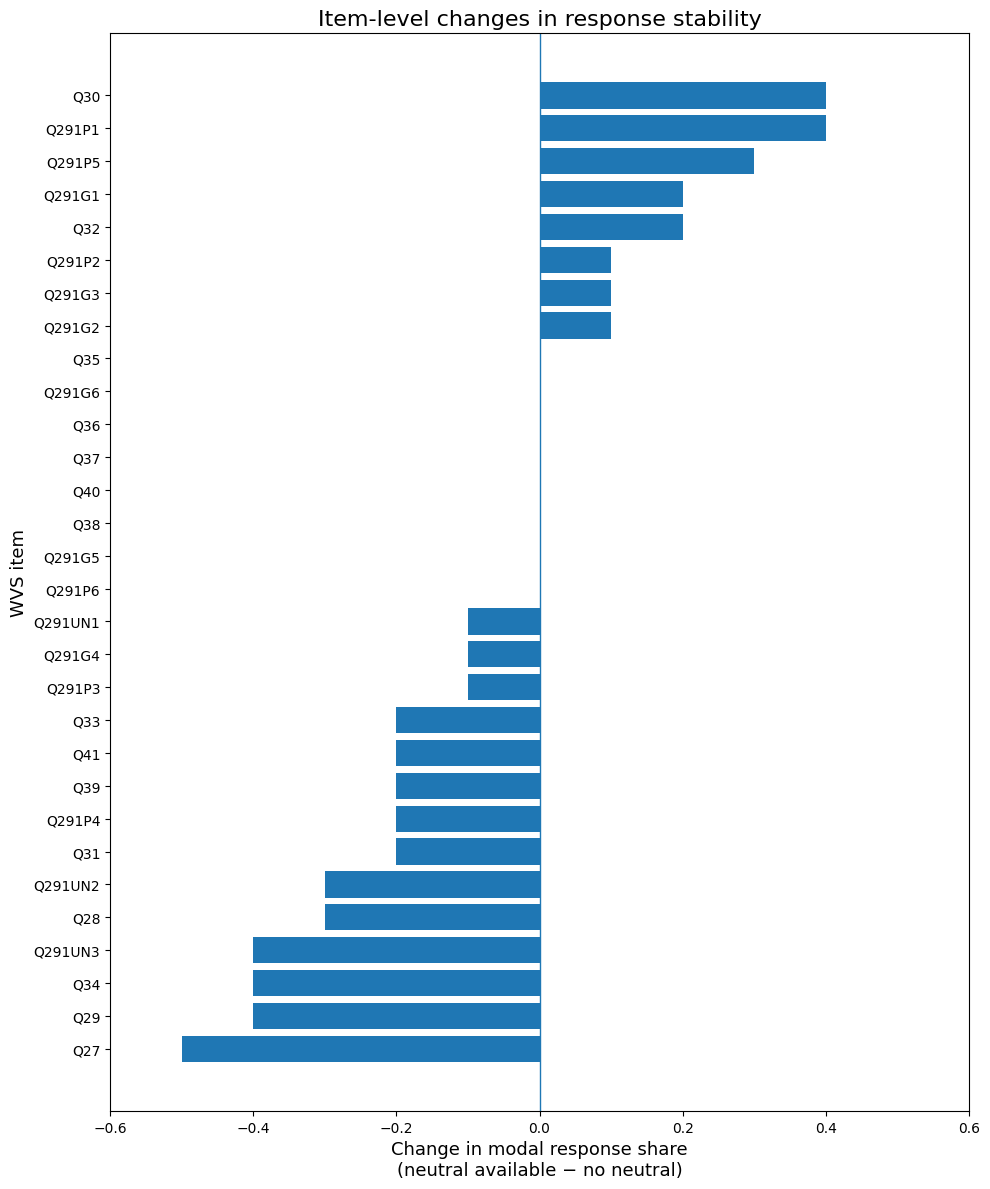

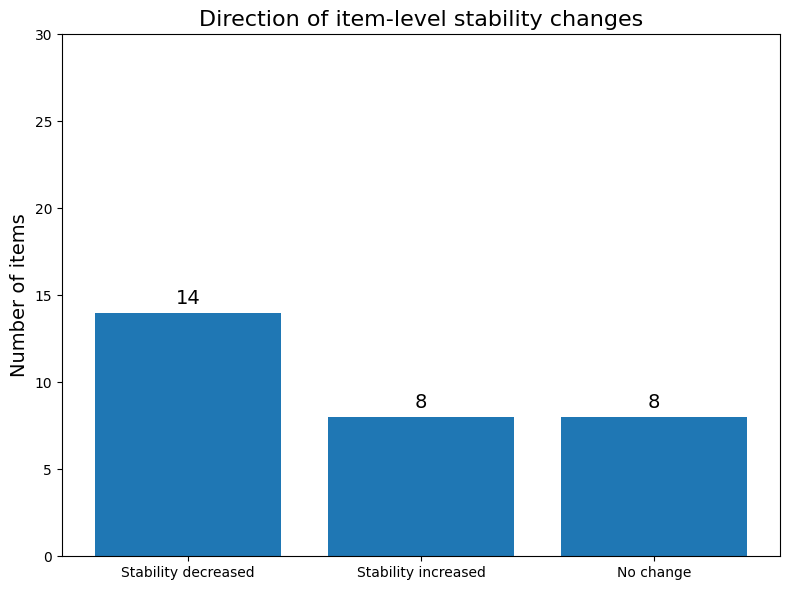

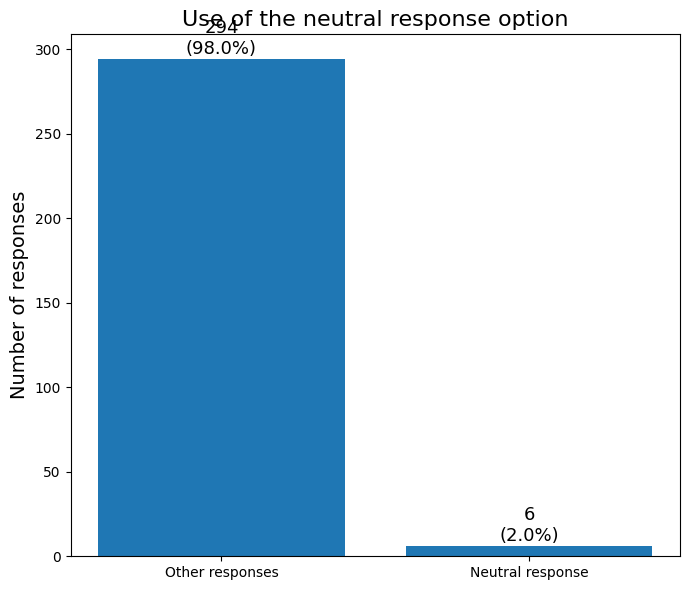


POSTER RESULTS
Mean stability — no neutral:     0.763
Mean stability — neutral:        0.703
Difference:                       -0.060

Items with decreased stability:  14
Items with increased stability:  8
Items with no change:             8

Neutral responses:                6/300
Neutral response rate:            2.00%


In [34]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# ============================================================
# 1. PREPARE DATA
# ============================================================

# Stability table
pivot = stability_df.pivot(
    index="item",
    columns="condition",
    values="stability"
)

pivot["change"] = (
    pivot["with_neutral"] -
    pivot["no_neutral"]
)

# Overall means
mean_no_neutral = pivot["no_neutral"].mean()
mean_neutral = pivot["with_neutral"].mean()
difference = mean_neutral - mean_no_neutral


# ============================================================
# 2. FIGURE 1 — OVERALL STABILITY
# ============================================================

plt.figure(figsize=(8, 6))

bars = plt.bar(
    ["No neutral\noption", "Neutral\navailable"],
    [mean_no_neutral, mean_neutral]
)

plt.ylabel("Mean modal response share", fontsize=14)
plt.title(
    "LLM response stability by response-option condition",
    fontsize=16
)

plt.ylim(0, 1)

for bar, value in zip(
    bars,
    [mean_no_neutral, mean_neutral]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        fontsize=14
    )

plt.text(
    0.5,
    0.08,
    f"Difference: {difference:+.3f}",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    "FIGURE_1_overall_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. FIGURE 2 — ITEM-LEVEL CHANGES
# ============================================================

plot_df = pivot.sort_values("change")

plt.figure(figsize=(10, 12))

bars = plt.barh(
    plot_df.index,
    plot_df["change"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Change in modal response share\n"
    "(neutral available − no neutral)",
    fontsize=13
)

plt.ylabel(
    "WVS item",
    fontsize=13
)

plt.title(
    "Item-level changes in response stability",
    fontsize=16
)

plt.xlim(-0.6, 0.6)

plt.tight_layout()

plt.savefig(
    "FIGURE_2_item_level_changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. FIGURE 3 — DIRECTION OF CHANGES
# ============================================================

decreased = (pivot["change"] < 0).sum()
increased = (pivot["change"] > 0).sum()
unchanged = (pivot["change"] == 0).sum()

labels = [
    "Stability decreased",
    "Stability increased",
    "No change"
]

counts = [
    decreased,
    increased,
    unchanged
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    counts
)

plt.ylabel(
    "Number of items",
    fontsize=14
)

plt.title(
    "Direction of item-level stability changes",
    fontsize=16
)

plt.ylim(0, 30)

for bar, value in zip(bars, counts):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        str(value),
        ha="center",
        fontsize=14
    )

plt.tight_layout()

plt.savefig(
    "FIGURE_3_direction_of_changes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. FIGURE 4 — NEUTRAL RESPONSE USAGE
# ============================================================

neutral_condition = df[
    (df["condition"] == "with_neutral") &
    (df["response"] != "UNPARSED")
].copy()

neutral_count = (
    neutral_condition["response"]
    == "Neither agree nor disagree"
).sum()

non_neutral_count = (
    len(neutral_condition) -
    neutral_count
)

neutral_percentage = (
    neutral_count /
    len(neutral_condition)
    * 100
)

plt.figure(figsize=(7, 6))

bars = plt.bar(
    ["Other responses", "Neutral response"],
    [non_neutral_count, neutral_count]
)

plt.ylabel(
    "Number of responses",
    fontsize=14
)

plt.title(
    "Use of the neutral response option",
    fontsize=16
)

for bar, value in zip(
    bars,
    [non_neutral_count, neutral_count]
):

    percentage = (
        value /
        len(neutral_condition)
        * 100
    )

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 3,
        f"{value}\n({percentage:.1f}%)",
        ha="center",
        fontsize=13
    )

plt.tight_layout()

plt.savefig(
    "FIGURE_4_neutral_usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. PRINT THE KEY RESULTS
# ============================================================

print("\n" + "=" * 50)
print("POSTER RESULTS")
print("=" * 50)

print(f"Mean stability — no neutral:     {mean_no_neutral:.3f}")
print(f"Mean stability — neutral:        {mean_neutral:.3f}")
print(f"Difference:                       {difference:+.3f}")

print()

print(f"Items with decreased stability:  {decreased}")
print(f"Items with increased stability:  {increased}")
print(f"Items with no change:             {unchanged}")

print()

print(
    f"Neutral responses:                "
    f"{neutral_count}/{len(neutral_condition)}"
)

print(
    f"Neutral response rate:            "
    f"{neutral_percentage:.2f}%"
)

print("=" * 50)